# EDA — 패턴 및 트렌드

| 섹션 | 내용 |
|------|------|
| **01-1** | 브랜드×카테고리별 일일 리뷰 유입 추이 (라인 플롯) |
| **01-2** | 대시보드 변화율 지표의 이동평균 윈도우 7일 결정 |
| **02** | 요일별 / 월별 계절성 히트맵 |

## 0. 공통 설정 — 라이브러리, 폰트, 데이터 로드

In [1]:
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings('ignore')

# ── 한글 폰트 ──────────────────────────────────────────────────────────────────
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    try:
        import koreanize_matplotlib  # noqa
    except ImportError:
        pass
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 ───────────────────────────────────────────────────────────────────────
BASE = "/Users/300phrnaver.com/Desktop/bootcamp/final_project/review_analysis_filluminate/phr/"

# ── 데이터 로드 ────────────────────────────────────────────────────────────────
reviews  = pd.read_csv(BASE + "cleaned_reviews.csv",  parse_dates=['작성일'], low_memory=False)
products = pd.read_csv(BASE + "cleaned_products.csv")

df = reviews.merge(products[['goodsNo', '브랜드', '카테고리']], on='goodsNo', how='left')
df['date'] = df['작성일'].dt.normalize()

brands     = sorted(df['브랜드'].dropna().unique())
categories = sorted(df['카테고리'].dropna().unique())

brand_colors = {'제멋': '#E07B54', '트래블': '#4A90D9', '필루미네이트': '#6ABF69'}

print(f"전체 기간: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"브랜드: {brands}")
print(f"카테고리: {categories}")
print(f"총 리뷰 수: {len(df):,}건")

전체 기간: 2015-08-13 ~ 2026-03-25
브랜드: ['제멋', '트래블', '필루미네이트']
카테고리: ['상의', '아우터', '하의']
총 리뷰 수: 685,292건


---
## 01-1. 브랜드×카테고리별 일일 리뷰 유입 추이
- 3행(브랜드) × 3열(카테고리) 그리드
- 일별 원본 + 7일 MA 중첩

저장 → eda_01_daily_review_trend.png


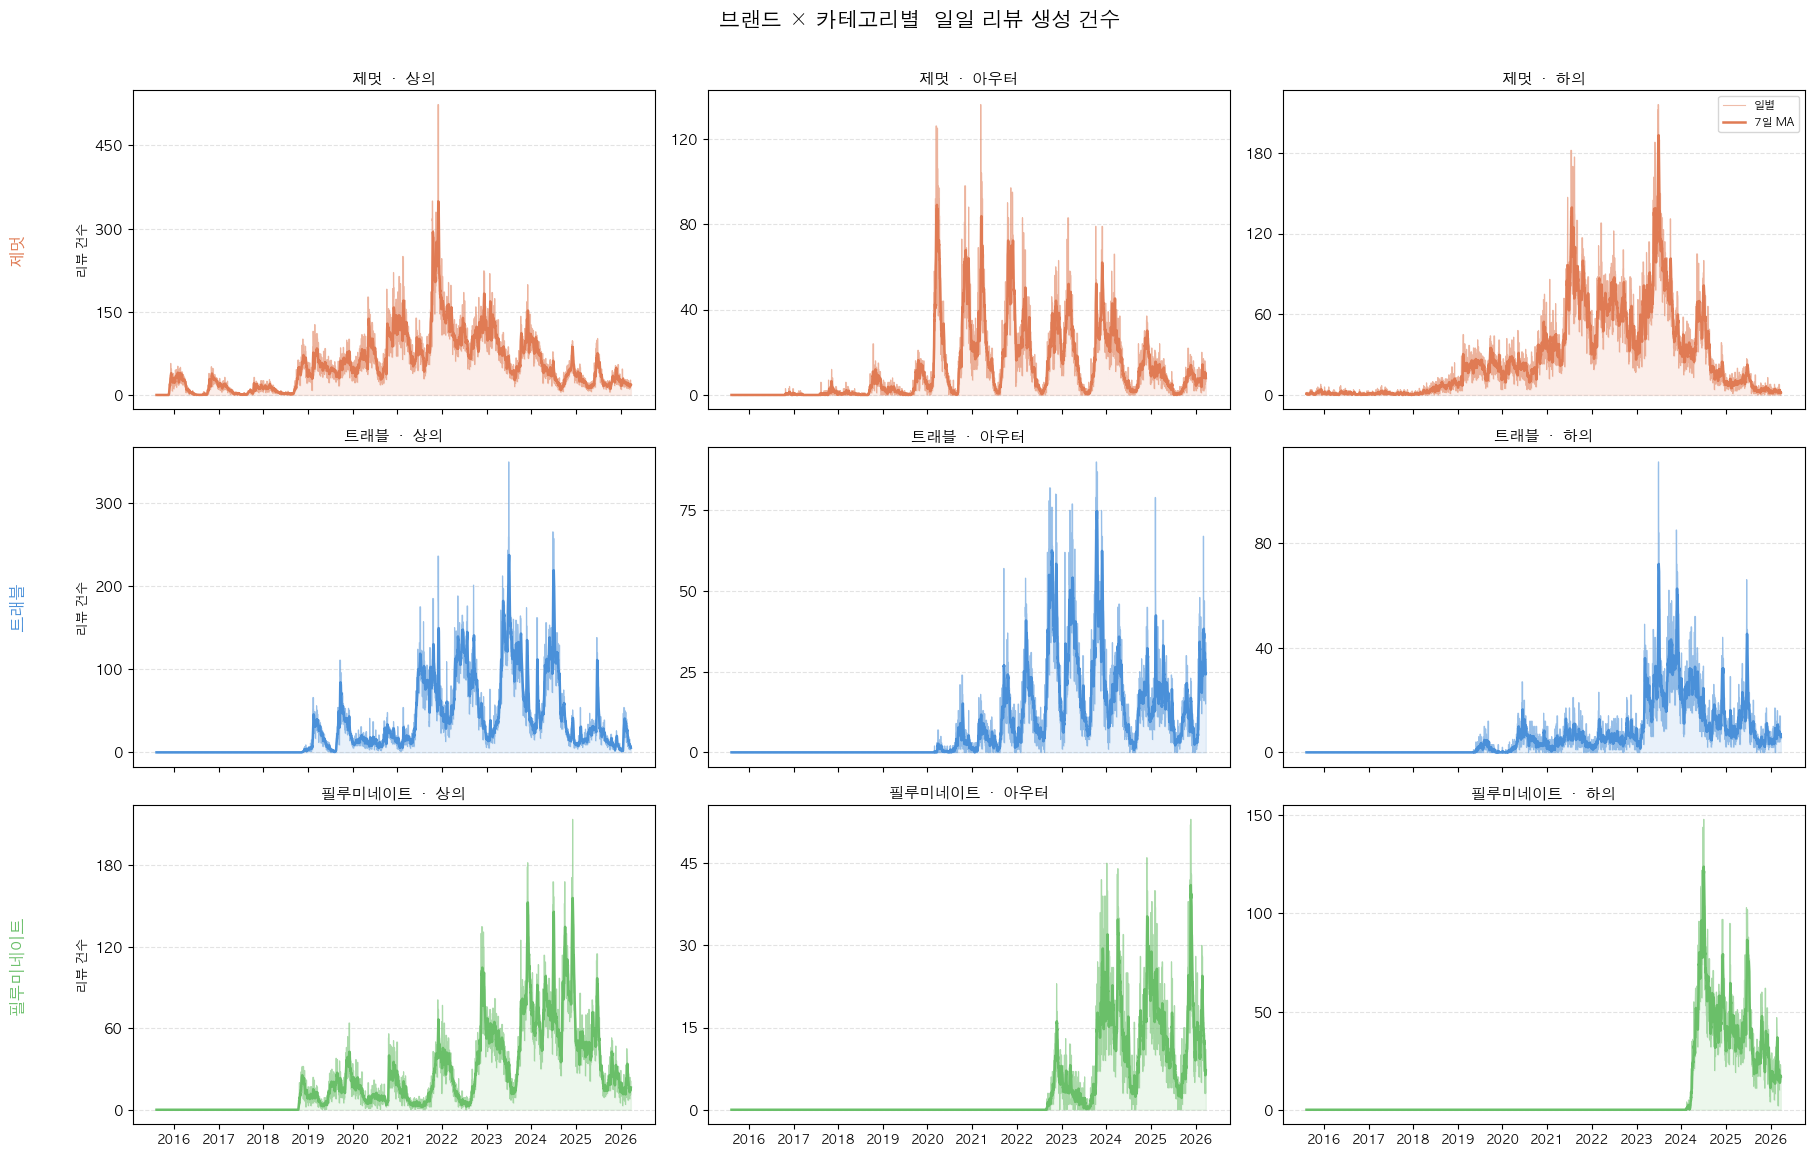

In [2]:
# 브랜드×카테고리별 일별 리뷰 집계
daily = (
    df.groupby(['브랜드', '카테고리', 'date'])
      .size()
      .reset_index(name='리뷰수')
      .sort_values('date')
)

n_brand = len(brands)
n_cat   = len(categories)

fig, axes = plt.subplots(
    nrows=n_brand, ncols=n_cat,
    figsize=(6 * n_cat, 3.8 * n_brand),
    sharex=True, sharey=False
)
axes = np.array(axes).reshape(n_brand, n_cat)

for r, brand in enumerate(brands):
    for c, cat in enumerate(categories):
        ax    = axes[r, c]
        color = brand_colors[brand]

        sub = (
            daily[(daily['브랜드'] == brand) & (daily['카테고리'] == cat)]
            .set_index('date')
            .reindex(pd.date_range(daily['date'].min(), daily['date'].max()))
            .fillna(0)
        )
        sub['MA7'] = sub['리뷰수'].rolling(7, min_periods=1).mean()

        ax.fill_between(sub.index, sub['리뷰수'], alpha=0.12, color=color)
        ax.plot(sub.index, sub['리뷰수'], lw=0.8, alpha=0.5, color=color, label='일별')
        ax.plot(sub.index, sub['MA7'],    lw=1.8, color=color,            label='7일 MA')

        ax.set_title(f"{brand}  ·  {cat}", fontsize=11, fontweight='bold', pad=5)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
        ax.grid(axis='y', linestyle='--', alpha=0.35)

        if c == 0:
            ax.set_ylabel("리뷰 건수", fontsize=9)
        if r == 0 and c == n_cat - 1:
            ax.legend(fontsize=8, loc='upper right')

        if r == n_brand - 1:
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)

# 브랜드 행 라벨
for r, brand in enumerate(brands):
    axes[r, 0].annotate(
        brand,
        xy=(-0.22, 0.5), xycoords='axes fraction',
        fontsize=12, fontweight='bold', rotation=90,
        va='center', ha='center',
        color=brand_colors[brand]
    )

fig.suptitle("브랜드 × 카테고리별  일일 리뷰 생성 건수",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(BASE + "eda_01_daily_review_trend.png", dpi=150, bbox_inches='tight')
print("저장 → eda_01_daily_review_trend.png")
plt.show()

---
## 01-2. 대시보드 변화율 지표의 이동평균 윈도우 7일 결정

1. 리뷰가 갑자기 튀는 날이 많아 일별 원본만 보면 왜곡 가능
2. 요일별 리뷰 편차가 작아(13~16% 균등) 7일이 공정한 주간 평균
3. CV·변화율 표준편차 비교 → 7일 최적

### 분석 3단계
- **Plot A**: 7 / 14 / 30일 MA 시각적 비교 (그룹 평균)
- **Plot B**: MA 안정성(CV) 비교 — 낮을수록 안정
- **Plot C**: 변화율 분포 비교 — 표준편차가 낮을수록 노이즈 적음

In [3]:
WINDOWS    = [7, 14, 30]
WIN_COLORS = ['#E07B54', '#4A90D9', '#6ABF69']

# 상품별 일별 리뷰 집계
daily_raw = (
    df.groupby(['goodsNo', '브랜드', '카테고리', 'date'])
      .size()
      .reset_index(name='리뷰수')
)

# 활성 상품 필터 (최근 1년 내 리뷰 있는 상품만)
stats = daily_raw.groupby(['goodsNo', '브랜드', '카테고리'])['리뷰수'].sum().reset_index()
stats.columns = ['goodsNo', '브랜드', '카테고리', '총리뷰']

active = df.groupby('goodsNo')['date'].agg(['min', 'max'])
active['활성일수'] = (active['max'] - active['min']).dt.days.clip(lower=1)
stats = stats.merge(active[['활성일수']], on='goodsNo')
stats['일평균'] = stats['총리뷰'] / stats['활성일수']

ACTIVE_CUTOFF = df['date'].max() - pd.Timedelta(days=365)
active_goods  = df[df['date'] >= ACTIVE_CUTOFF]['goodsNo'].unique()
stats_active  = stats[stats['goodsNo'].isin(active_goods)].copy()

print(f"활성 상품 수 (최근 1년 기준): {len(stats_active):,}개 / 전체 {len(stats):,}개")

활성 상품 수 (최근 1년 기준): 1,437개 / 전체 2,554개


저장 → eda_01_n_ma_smoothness.png


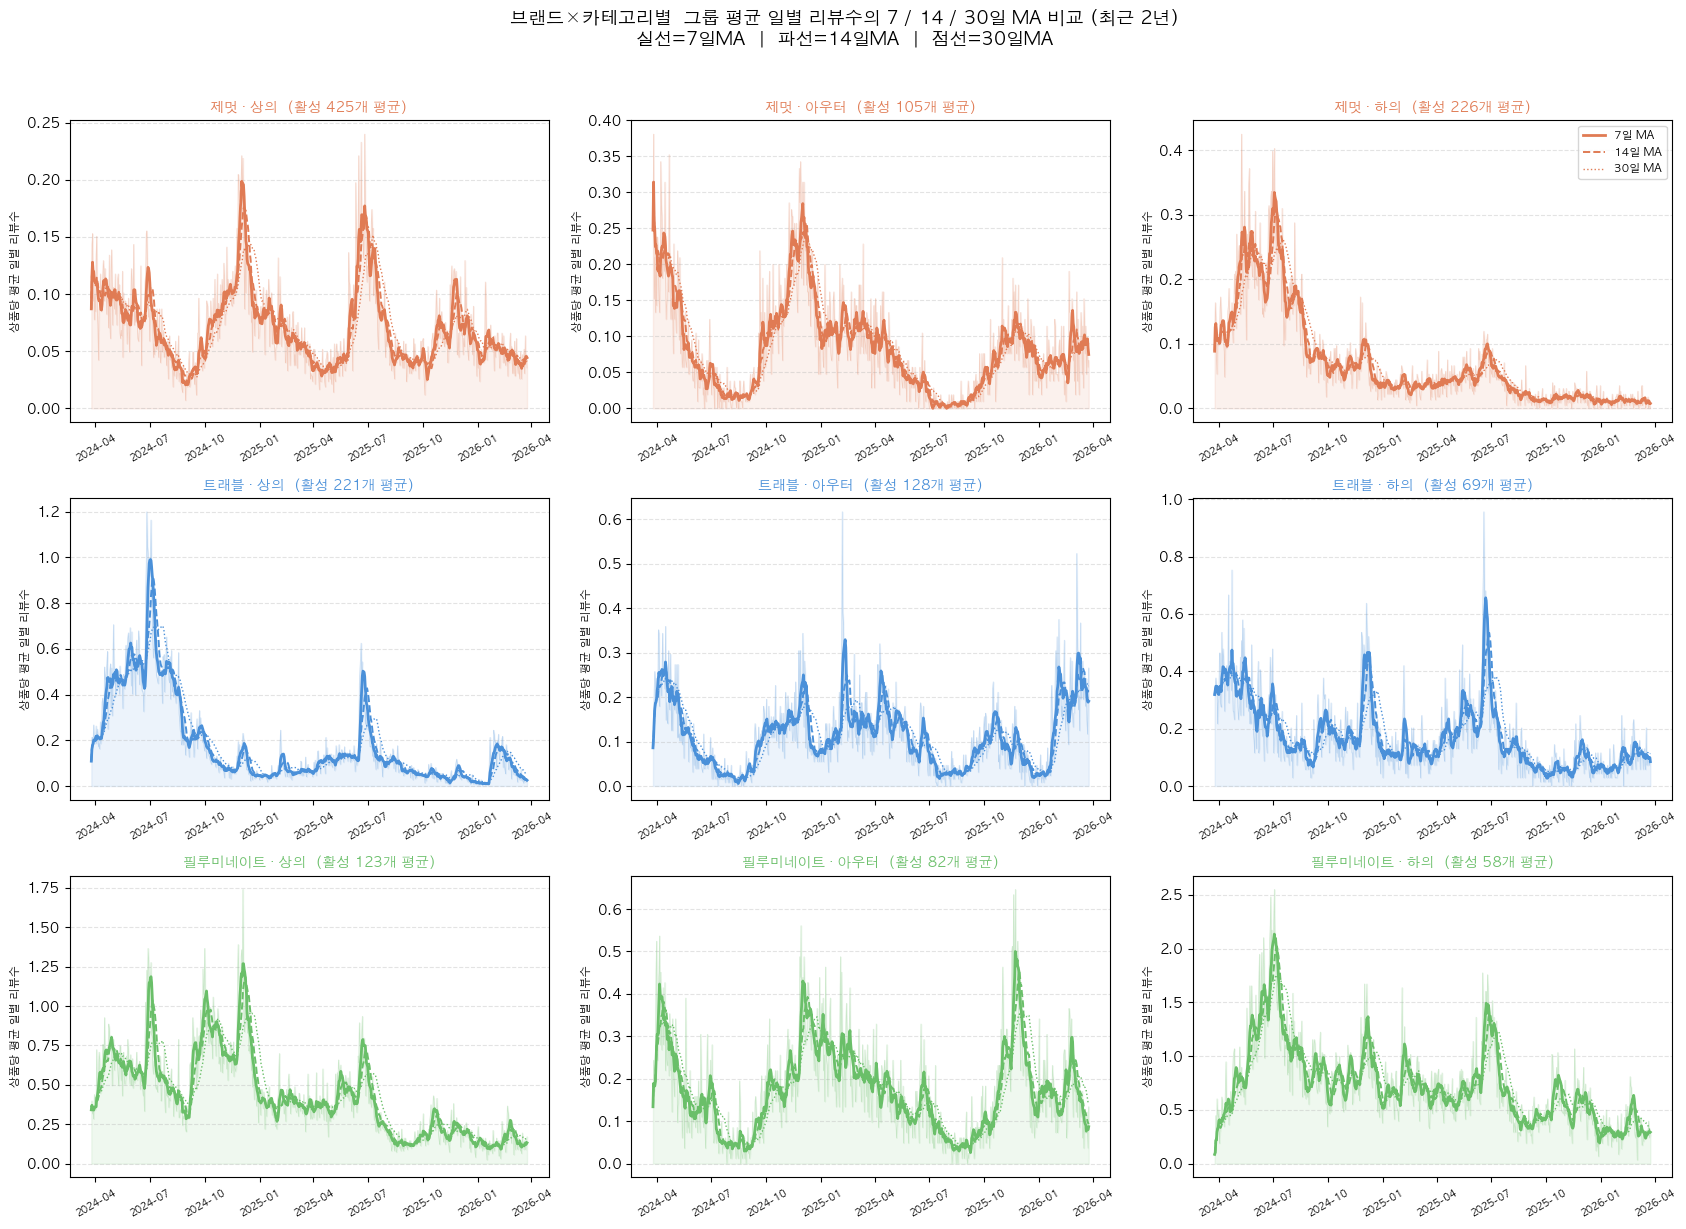

In [4]:
# ── Plot A: 7/14/30일 MA 시각적 비교 (최근 2년, 그룹 평균) ───────────────────
cutoff_2y = df['date'].max() - pd.Timedelta(days=730)
date_2y   = pd.date_range(cutoff_2y, df['date'].max(), freq='D')

fig1, axes1 = plt.subplots(3, 3, figsize=(17, 12), sharex=False)

for r, brand in enumerate(brands):
    for c, cat in enumerate(categories):
        ax    = axes1[r, c]
        color = brand_colors[brand]

        active_gnos = stats_active[
            (stats_active['브랜드'] == brand) & (stats_active['카테고리'] == cat)
        ]['goodsNo'].tolist()
        n_products = len(active_gnos)

        if n_products == 0:
            ax.set_visible(False)
            continue

        group_daily = (
            daily_raw[daily_raw['goodsNo'].isin(active_gnos)]
            .groupby('date')['리뷰수']
            .sum()
            .reindex(date_2y, fill_value=0)
        ) / n_products

        ma7  = group_daily.rolling(7,  min_periods=1).mean()
        ma14 = group_daily.rolling(14, min_periods=1).mean()
        ma30 = group_daily.rolling(30, min_periods=1).mean()

        ax.fill_between(group_daily.index, group_daily.values, alpha=0.1, color=color)
        ax.plot(group_daily.index, group_daily.values, lw=0.5, alpha=0.25, color=color)
        ax.plot(ma7.index,  ma7.values,  lw=2.0, color=color, linestyle='-',  label='7일 MA')
        ax.plot(ma14.index, ma14.values, lw=1.4, color=color, linestyle='--', label='14일 MA')
        ax.plot(ma30.index, ma30.values, lw=1.0, color=color, linestyle=':',  label='30일 MA')

        ax.set_title(f"{brand} · {cat}  (활성 {n_products}개 평균)",
                     fontsize=10, fontweight='bold', color=color)
        ax.set_ylabel("상품당 평균 일별 리뷰수", fontsize=8)
        ax.tick_params(axis='x', labelsize=7, rotation=30)
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        if r == 0 and c == 2:
            ax.legend(fontsize=8, loc='upper right')

fig1.suptitle(
    "브랜드×카테고리별  그룹 평균 일별 리뷰수의 7 / 14 / 30일 MA 비교 (최근 2년)\n"
    "실선=7일MA  |  파선=14일MA  |  점선=30일MA",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(BASE + "eda_01_n_ma_smoothness.png", dpi=150, bbox_inches='tight')
print("저장 → eda_01_n_ma_smoothness.png")
plt.show()

In [5]:
# ── 공통: 9개 그룹 평균 시계열 생성 ──────────────────────────────────────────
group_series = {}
for brand in brands:
    for cat in categories:
        active_gnos = stats_active[
            (stats_active['브랜드'] == brand) & (stats_active['카테고리'] == cat)
        ]['goodsNo'].tolist()
        if not active_gnos:
            continue
        n_prod = len(active_gnos)
        series = (
            daily_raw[daily_raw['goodsNo'].isin(active_gnos)]
            .groupby('date')['리뷰수']
            .sum()
            .reindex(pd.date_range(df['date'].min(), df['date'].max(), freq='D'), fill_value=0)
        ) / n_prod
        group_series[(brand, cat)] = series

print(f"그룹 수: {len(group_series)}개")

그룹 수: 9개


저장 → eda_01_n_ma_stability_cv.png


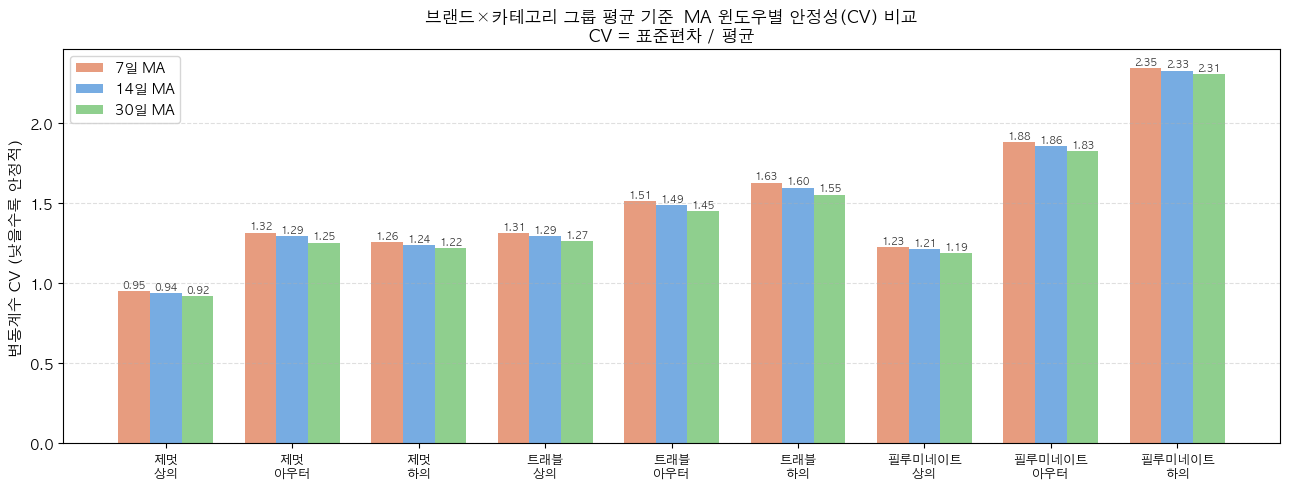

In [6]:
# ── Plot B: MA 안정성(CV) 바 차트 ────────────────────────────────────────────
cv_records = []
for (brand, cat), series in group_series.items():
    for w in WINDOWS:
        ma = series.rolling(w, min_periods=w).mean().dropna()
        if len(ma) < 10:
            continue
        cv = ma.std() / ma.mean() if ma.mean() > 0 else np.nan
        cv_records.append({'브랜드': brand, '카테고리': cat, 'window': w, 'CV': cv})

cv_df = pd.DataFrame(cv_records)
cv_df['그룹'] = cv_df['브랜드'] + '\n' + cv_df['카테고리']
group_order = [f"{b}\n{c}" for b in brands for c in categories if (b, c) in group_series]

fig2, ax2 = plt.subplots(figsize=(13, 5))
x     = np.arange(len(group_order))
width = 0.25

for i, (w, wc) in enumerate(zip(WINDOWS, WIN_COLORS)):
    cv_vals = [
        cv_df[(cv_df['그룹'] == g) & (cv_df['window'] == w)]['CV'].values[0]
        if len(cv_df[(cv_df['그룹'] == g) & (cv_df['window'] == w)]) > 0 else np.nan
        for g in group_order
    ]
    bars = ax2.bar(x + (i - 1) * width, cv_vals, width=width,
                   color=wc, alpha=0.75, label=f'{w}일 MA')
    for bar, val in zip(bars, cv_vals):
        if not np.isnan(val):
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.02,
                     f'{val:.2f}', ha='center', fontsize=7, color='#333')

ax2.set_xticks(x)
ax2.set_xticklabels(group_order, fontsize=9)
ax2.set_ylabel("변동계수 CV (낮을수록 안정적)", fontsize=11)
ax2.set_title("브랜드×카테고리 그룹 평균 기준  MA 윈도우별 안정성(CV) 비교\nCV = 표준편차 / 평균",
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(BASE + "eda_01_n_ma_stability_cv.png", dpi=150, bbox_inches='tight')
print("저장 → eda_01_n_ma_stability_cv.png")
plt.show()

저장 → eda_01_n_change_rate_noise.png


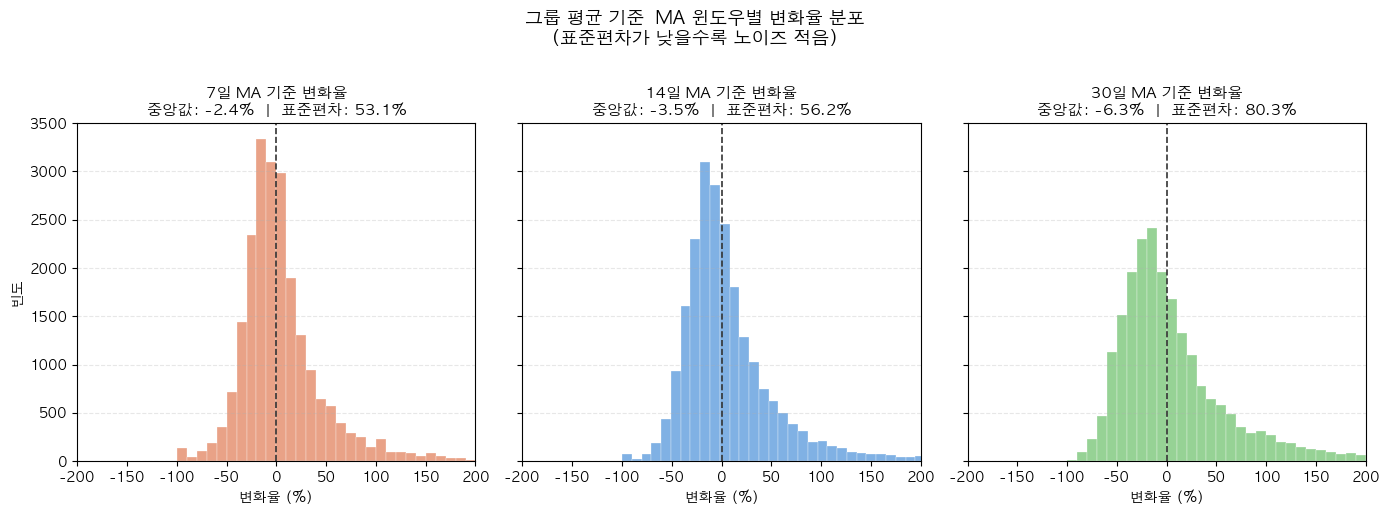

In [7]:
# ── Plot C: 변화율 분포 히스토그램 ───────────────────────────────────────────
change_records = []
for (brand, cat), series in group_series.items():
    for w in WINDOWS:
        ma = series.rolling(w, min_periods=w).mean()
        change_rate = ((ma - ma.shift(w)) / ma.shift(w).replace(0, np.nan) * 100).dropna()
        for v in change_rate.values:
            if abs(v) < 500:
                change_records.append({'브랜드': brand, '카테고리': cat,
                                       'window': w, 'change_rate': v})

change_df = pd.DataFrame(change_records)

fig3, axes3 = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, w, color in zip(axes3, WINDOWS, WIN_COLORS):
    vals = change_df[change_df['window'] == w]['change_rate']
    ax.hist(vals, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='#333', lw=1.2, linestyle='--')
    std = vals.std()
    med = vals.median()
    ax.set_title(f"{w}일 MA 기준 변화율\n중앙값: {med:.1f}%  |  표준편차: {std:.1f}%",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("변화율 (%)", fontsize=10)
    ax.set_xlim(-200, 200)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes3[0].set_ylabel("빈도", fontsize=10)
fig3.suptitle("그룹 평균 기준  MA 윈도우별 변화율 분포\n(표준편차가 낮을수록 노이즈 적음)",
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + "eda_01_n_change_rate_noise.png", dpi=150, bbox_inches='tight')
print("저장 → eda_01_n_change_rate_noise.png")
plt.show()

In [8]:
# ── 요약 테이블 ───────────────────────────────────────────────────────────────
print("=" * 55)
print("  n일 MA 기준 비교 요약 (그룹 평균 기준)")
print("=" * 55)
print(f"{'윈도우':>8} | {'CV 중앙값':>10} | {'변화율 표준편차':>14}")
print("-" * 40)
for w in WINDOWS:
    cv_med = cv_df[cv_df['window'] == w]['CV'].median()
    cr_std = change_df[change_df['window'] == w]['change_rate'].std()
    print(f"  {w}일 MA | {cv_med:>10.3f} | {cr_std:>12.1f}%")
print("=" * 55)
print("\n→ CV 개선폭 미미 + 30일 변화율 표준편차 오히려 증가 → 7일 MA 최적")

  n일 MA 기준 비교 요약 (그룹 평균 기준)
     윈도우 |     CV 중앙값 |       변화율 표준편차
----------------------------------------
  7일 MA |      1.317 |         53.1%
  14일 MA |      1.295 |         56.2%
  30일 MA |      1.266 |         80.3%

→ CV 개선폭 미미 + 30일 변화율 표준편차 오히려 증가 → 7일 MA 최적


---
## 02. 요일별 / 월별 계절성 히트맵
- 2023~2025 안정기 데이터 기준
- 절대값 + 행 정규화(%) 두 가지로 비교

In [9]:
# 공통 전처리
df['요일']  = df['작성일'].dt.dayofweek   # 0=월 ~ 6=일
df['월']    = df['작성일'].dt.month
df['연도']  = df['작성일'].dt.year
df['브랜드_카테고리'] = df['브랜드'] + ' · ' + df['카테고리']

df_recent = df[df['연도'].isin([2023, 2024, 2025])].copy()

DOW_LABELS = ['월', '화', '수', '목', '금', '토', '일']
MON_LABELS = ['1월','2월','3월','4월','5월','6월',
              '7월','8월','9월','10월','11월','12월']

BC_ORDER = [
    '제멋 · 상의', '제멋 · 아우터', '제멋 · 하의',
    '트래블 · 상의', '트래블 · 아우터', '트래블 · 하의',
    '필루미네이트 · 상의', '필루미네이트 · 아우터', '필루미네이트 · 하의',
]

print(f"분석 기간: {df_recent['date'].min().date()} ~ {df_recent['date'].max().date()}")
print(f"리뷰 수: {len(df_recent):,}건")

분석 기간: 2023-01-01 ~ 2025-12-31
리뷰 수: 324,930건


저장 → eda_02a_heatmap_dayofweek.png


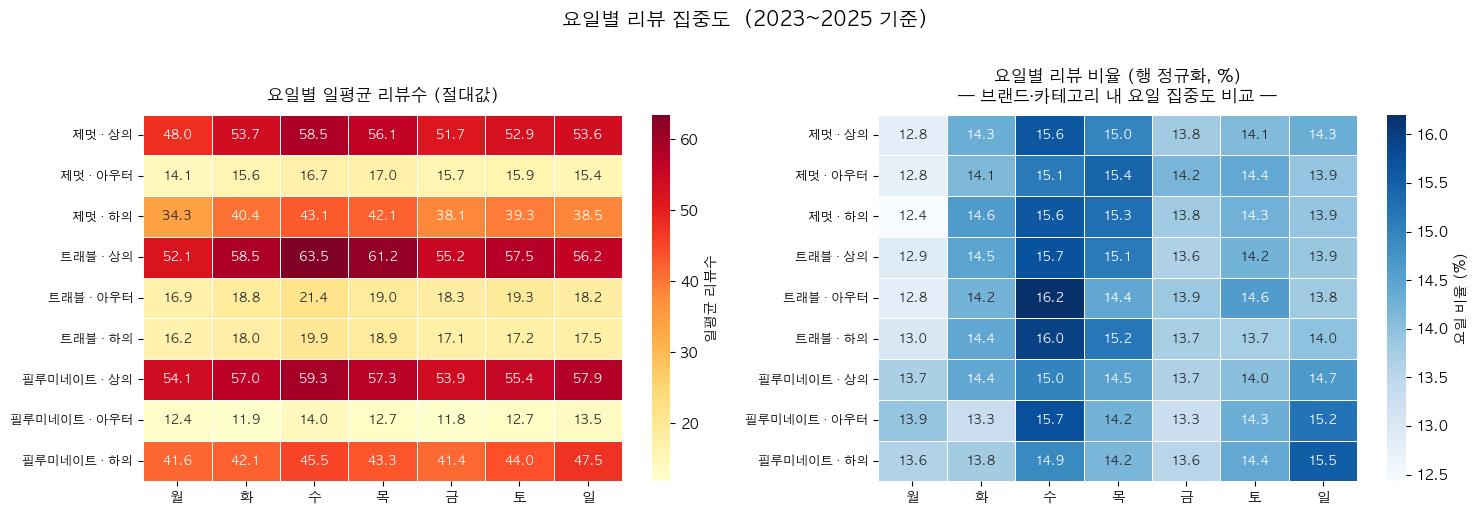


주중 평균: 14.3% / 주말 평균: 14.3%


In [10]:
# ── Plot 1: 요일별 리뷰 집중도 히트맵 ────────────────────────────────────────
daily_cnt = (
    df_recent.groupby(['브랜드_카테고리', 'date', '요일'])
             .size()
             .reset_index(name='리뷰수')
)
dow_avg = (
    daily_cnt.groupby(['브랜드_카테고리', '요일'])['리뷰수']
             .mean()
             .reset_index()
)
dow_pivot = (
    dow_avg.pivot(index='브랜드_카테고리', columns='요일', values='리뷰수')
           .reindex(index=BC_ORDER)
)
dow_pivot.columns = DOW_LABELS
dow_norm = dow_pivot.div(dow_pivot.sum(axis=1), axis=0) * 100

fig1, axes = plt.subplots(1, 2, figsize=(15, 5),
                          gridspec_kw={'width_ratios': [1, 1]})

sns.heatmap(dow_pivot, ax=axes[0], cmap='YlOrRd',
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': '일평균 리뷰수'}, annot_kws={'size': 9})
axes[0].set_title('요일별 일평균 리뷰수 (절대값)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', labelsize=9, rotation=0)

sns.heatmap(dow_norm, ax=axes[1], cmap='Blues',
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': '요일 비율 (%)'}, annot_kws={'size': 9})
axes[1].set_title('요일별 리뷰 비율 (행 정규화, %)\n— 브랜드·카테고리 내 요일 집중도 비교 —',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', labelsize=10)
axes[1].tick_params(axis='y', labelsize=9, rotation=0)

fig1.suptitle('요일별 리뷰 집중도  (2023~2025 기준)',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + "eda_02a_heatmap_dayofweek.png", dpi=150, bbox_inches='tight')
print("저장 → eda_02a_heatmap_dayofweek.png")
plt.show()

# 요약
weekday = dow_norm[['월','화','수','목','금']].mean(axis=1).mean()
weekend = dow_norm[['토','일']].mean(axis=1).mean()
print(f"\n주중 평균: {weekday:.1f}% / 주말 평균: {weekend:.1f}%")

저장 → eda_02b_heatmap_monthly.png


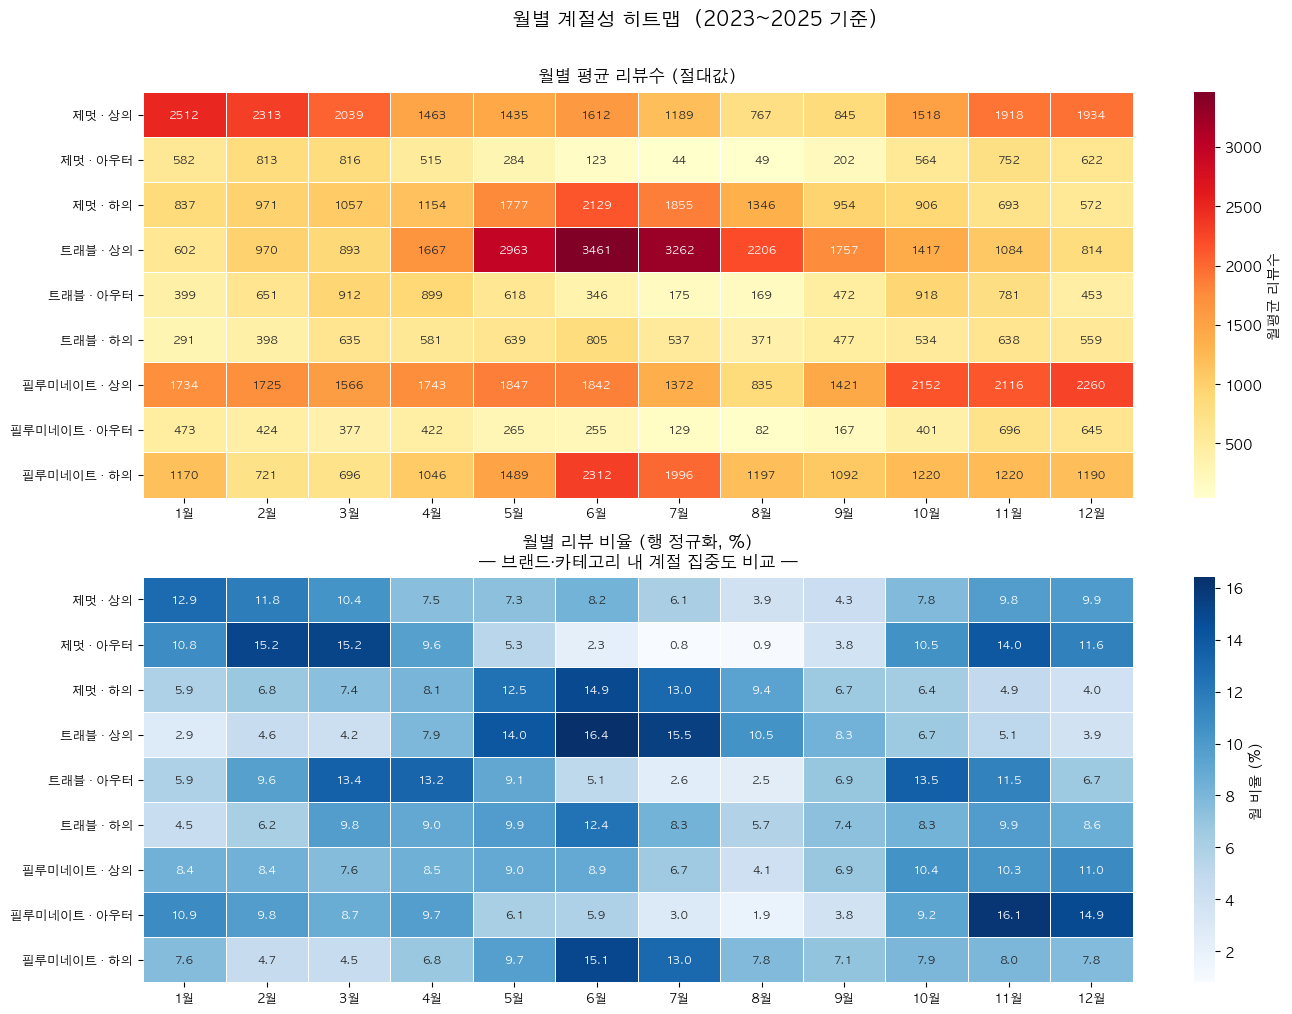


  월별 계절성 요약 (카테고리별 피크월)
  제멋 · 상의                → 피크: 1월  (2512건)
  제멋 · 아우터               → 피크: 3월  (816건)
  제멋 · 하의                → 피크: 6월  (2129건)
  트래블 · 상의               → 피크: 6월  (3461건)
  트래블 · 아우터              → 피크: 10월  (918건)
  트래블 · 하의               → 피크: 6월  (805건)
  필루미네이트 · 상의            → 피크: 12월  (2260건)
  필루미네이트 · 아우터           → 피크: 11월  (696건)
  필루미네이트 · 하의            → 피크: 6월  (2312건)


In [11]:
# ── Plot 2: 월별 계절성 히트맵 ───────────────────────────────────────────────
monthly_cnt = (
    df_recent.groupby(['브랜드_카테고리', '연도', '월'])
             .size()
             .reset_index(name='리뷰수')
)
mon_avg = (
    monthly_cnt.groupby(['브랜드_카테고리', '월'])['리뷰수']
               .mean()
               .reset_index()
)
mon_pivot = (
    mon_avg.pivot(index='브랜드_카테고리', columns='월', values='리뷰수')
           .reindex(index=BC_ORDER)
)
mon_pivot.columns = MON_LABELS
mon_norm = mon_pivot.div(mon_pivot.sum(axis=1), axis=0) * 100

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10))

sns.heatmap(mon_pivot, ax=axes2[0], cmap='YlOrRd',
            annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': '월평균 리뷰수'}, annot_kws={'size': 8})
axes2[0].set_title('월별 평균 리뷰수 (절대값)', fontsize=12, fontweight='bold', pad=8)
axes2[0].set_xlabel('')
axes2[0].set_ylabel('')
axes2[0].tick_params(axis='x', labelsize=9)
axes2[0].tick_params(axis='y', labelsize=9, rotation=0)

sns.heatmap(mon_norm, ax=axes2[1], cmap='Blues',
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': '월 비율 (%)'}, annot_kws={'size': 8})
axes2[1].set_title('월별 리뷰 비율 (행 정규화, %)\n— 브랜드·카테고리 내 계절 집중도 비교 —',
                   fontsize=12, fontweight='bold', pad=8)
axes2[1].set_xlabel('')
axes2[1].set_ylabel('')
axes2[1].tick_params(axis='x', labelsize=9)
axes2[1].tick_params(axis='y', labelsize=9, rotation=0)

fig2.suptitle('월별 계절성 히트맵  (2023~2025 기준)',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(BASE + "eda_02b_heatmap_monthly.png", dpi=150, bbox_inches='tight')
print("저장 → eda_02b_heatmap_monthly.png")
plt.show()

# 요약
print("\n" + "="*50)
print("  월별 계절성 요약 (카테고리별 피크월)")
print("="*50)
for bc in BC_ORDER:
    peak_mon = mon_pivot.loc[bc].idxmax()
    peak_val = mon_pivot.loc[bc].max()
    print(f"  {bc:22s} → 피크: {peak_mon}  ({peak_val:.0f}건)")